In [2]:
# import all libraries 

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

In [4]:
# Timeline of major events in Earth's history
# Ages are in billions of years ago (Ga)

events = pd.DataFrame({
    "event": [
        "Earth forms",
        "Liquid water appears",
        "First possible life (chemical traces)",
        "Oldest stromatolites (Pilbara, Australia)",
        "Stromatolites widespread",
        "Great Oxidation Event begins",
        "Oxygen reaches 1% of atmosphere",
        "First complex cells (Eukaryotes)",
        "First multicellular life",
        "Cambrian Explosion (animals)",
        "First land plants",
        "First dinosaurs",
        "Mass extinction (dinosaurs)",
        "First humans",
        "Today"
    ],
    "age_ga": [
        4.54, 4.40, 4.10, 3.48, 3.00,
        2.45, 2.30, 1.85, 1.20, 0.54,
        0.47, 0.23, 0.066, 0.003, 0.0
    ],
    "category": [
        "Earth History", "Earth History", "Life", "Life", "Life",
        "Atmosphere", "Atmosphere", "Life", "Life", "Life",
        "Life", "Life", "Life", "Life", "Today"
    ]
})

# Sort by age
events = events.sort_values("age_ga", ascending=False).reset_index(drop=True)

#data set created 

print(f"\n📊 {len(events)} events spanning {events.age_ga.max()} billion years")
print("\nFirst few events:")
print(events[["event", "age_ga", "category"]].head(8).to_string(index=False))


📊 15 events spanning 4.54 billion years

First few events:
                                    event  age_ga      category
                              Earth forms    4.54 Earth History
                     Liquid water appears    4.40 Earth History
    First possible life (chemical traces)    4.10          Life
Oldest stromatolites (Pilbara, Australia)    3.48          Life
                 Stromatolites widespread    3.00          Life
             Great Oxidation Event begins    2.45    Atmosphere
          Oxygen reaches 1% of atmosphere    2.30    Atmosphere
         First complex cells (Eukaryotes)    1.85          Life


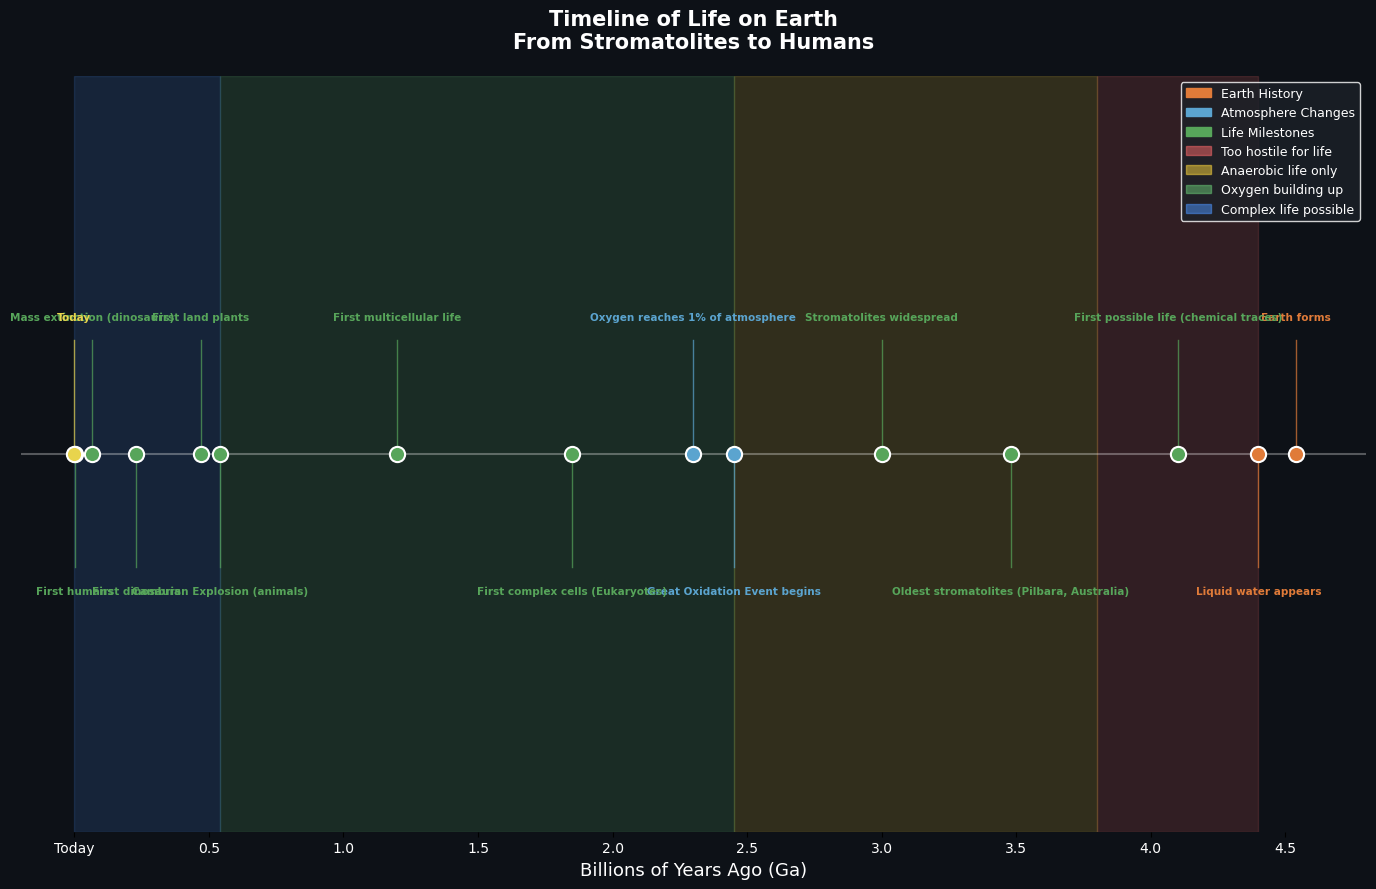

In [7]:
#  main visualization 

# Color scheme for each category
colors = {
    "Earth History": "#E07B39",
    "Atmosphere":    "#5BA4CF",
    "Life":          "#57A55A",
    "Today":         "#E8D44D"
}

# Habitability periods
habitable_periods = [
    {"start": 4.40, "end": 3.80, "label": "Early Ocean\n(too hot, meteor bombardment)", "color": "#FF6B6B", "alpha": 0.15},
    {"start": 3.80, "end": 2.45, "label": "Anaerobic Life Window\n(no oxygen, only microbes)", "color": "#FFD93D", "alpha": 0.15},
    {"start": 2.45, "end": 0.54, "label": "Oxygen Builds Up\n(complex life becomes possible)", "color": "#6BCB77", "alpha": 0.15},
    {"start": 0.54, "end": 0.00, "label": "Complex Life Window\n(animals, plants, humans)", "color": "#4D96FF", "alpha": 0.15},
]

# Create the figure
fig, ax = plt.subplots(figsize=(14, 9))

# Draw habitability background bands
for period in habitable_periods:
    ax.axvspan(period["end"], period["start"],
               alpha=period["alpha"],
               color=period["color"],
               label=period["label"])

# Draw the timeline line
ax.axhline(y=0, color="white", linewidth=1.5, alpha=0.3, zorder=1)

# Plot each event as a dot and label
for i, row in events.iterrows():
    color = colors[row["category"]]
    
    # Alternate labels above and below to avoid overlap
    y_pos = 0.3 if i % 2 == 0 else -0.3
    
    # Draw dot on timeline
    ax.scatter(row["age_ga"], 0, 
               color=color, s=120, zorder=5, 
               edgecolors="white", linewidth=1.5)
    
    # Draw vertical line to label
    ax.plot([row["age_ga"], row["age_ga"]], [0, y_pos],
            color=color, linewidth=1, alpha=0.7, zorder=3)
    
    # Add label
    ax.text(row["age_ga"], y_pos + (0.05 if y_pos > 0 else -0.05),
            row["event"],
            ha="center",
            va="bottom" if y_pos > 0 else "top",
            fontsize=7.5,
            color=color,
            fontweight="bold",
            wrap=True)

# Formatting
ax.set_xlim(-0.2, 4.8)
ax.set_ylim(-1.0, 1.0)
ax.set_xlabel("Billions of Years Ago (Ga)", fontsize=13, color="white")
ax.set_title("Timeline of Life on Earth\nFrom Stromatolites to Humans",
             fontsize=15, fontweight="bold", color="white", pad=20)

# X axis labels
ax.set_xticks([0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5])
ax.set_xticklabels(["Today", "0.5", "1.0", "1.5", "2.0", "2.5", "3.0", "3.5", "4.0", "4.5"],
                    color="white", fontsize=10)
ax.yaxis.set_visible(False)

# Dark background
ax.set_facecolor("#0D1117")
fig.patch.set_facecolor("#0D1117")

# Remove spines
for spine in ax.spines.values():
    spine.set_visible(False)

# Legend for categories
legend_elements = [
    mpatches.Patch(color=colors["Earth History"], label="Earth History"),
    mpatches.Patch(color=colors["Atmosphere"],    label="Atmosphere Changes"),
    mpatches.Patch(color=colors["Life"],          label="Life Milestones"),
    mpatches.Patch(color="#FF6B6B", alpha=0.5,    label="Too hostile for life"),
    mpatches.Patch(color="#FFD93D", alpha=0.5,    label="Anaerobic life only"),
    mpatches.Patch(color="#6BCB77", alpha=0.5,    label="Oxygen building up"),
    mpatches.Patch(color="#4D96FF", alpha=0.5,    label="Complex life possible"),
]
ax.legend(handles=legend_elements, loc="upper right",
          fontsize=9, facecolor="#1C2128", labelcolor="white",
          edgecolor="white", framealpha=0.8)

plt.tight_layout()
import os
os.makedirs("results/figures", exist_ok=True)
plt.savefig("results/figures/stromatolite_timeline.png", 
            dpi=150, bbox_inches="tight",
            facecolor="#0D1117")
plt.show()



In [10]:
# Astrobiology Implications
# What does Earth's timeline tell us about finding life elsewhere?

implications = pd.DataFrame({
    "finding": [
        "Life appeared very quickly after Earth cooled",
        "Microbial life dominated for 3 billion years",
        "Oxygen took 2 billion years to build up",
        "Complex life needs oxygenated atmosphere",
        "Stromatolites are detectable biosignatures",
    ],
    "time_taken": [
        "~300 million years after liquid water",
        "3.0 billion years",
        "2.0 billion years",
        "1.85 billion years after first life",
        "Visible for 3.5 billion years",
    ],
    "implication_for_other_planets": [
        "Life may start quickly wherever conditions allow",
        "Most life in universe is probably microbial",
        "Don't expect oxygen on young planets",
        "Complex life requires very old, stable planets",
        "Look for layered mineral deposits on Mars/Europa",
    ]
})

print("🌌 ASTROBIOLOGY IMPLICATIONS FROM EARTH'S STROMATOLITE RECORD")
print("=" * 70)
for _, row in implications.iterrows():
    print(f"\n🔬 Finding: {row['finding']}")
    print(f"   ⏱  Time: {row['time_taken']}")
    print(f"   🪐 Implication: {row['implication_for_other_planets']}")

print("\n" + "=" * 70)
print("\n💡 KEY INSIGHT FOR LIFE SEARCH:")
print("""
   Earth spent 88% of its inhabited history as a purely microbial world.
   If this is typical, then most inhabited planets we find will show
   MICROBIAL biosignatures — not complex life or intelligence.
   
   Stromatolite-like structures on Mars or Europa would be one of
   the greatest scientific discoveries in human history.
""")

🌌 ASTROBIOLOGY IMPLICATIONS FROM EARTH'S STROMATOLITE RECORD

🔬 Finding: Life appeared very quickly after Earth cooled
   ⏱  Time: ~300 million years after liquid water
   🪐 Implication: Life may start quickly wherever conditions allow

🔬 Finding: Microbial life dominated for 3 billion years
   ⏱  Time: 3.0 billion years
   🪐 Implication: Most life in universe is probably microbial

🔬 Finding: Oxygen took 2 billion years to build up
   ⏱  Time: 2.0 billion years
   🪐 Implication: Don't expect oxygen on young planets

🔬 Finding: Complex life needs oxygenated atmosphere
   ⏱  Time: 1.85 billion years after first life
   🪐 Implication: Complex life requires very old, stable planets

🔬 Finding: Stromatolites are detectable biosignatures
   ⏱  Time: Visible for 3.5 billion years
   🪐 Implication: Look for layered mineral deposits on Mars/Europa


💡 KEY INSIGHT FOR LIFE SEARCH:

   Earth spent 88% of its inhabited history as a purely microbial world.
   If this is typical, then most inhabite